In [1]:
import main
import util

import numpy as np
import matplotlib.pyplot as plt

In [2]:

def mixup_data(n_ways, X, y, lam_):
    """
    Mixes data n ways with itself shuffled without overlaps, returns X_mixed and an array of every y shuffling
    Example:
        mixup_data(3, X, y, (.5, .5, 0)) will return X_mixed, y[permutation0], y[permutation1], y[permutation2]
        and X_mixed will veriy X_mixed = .5*X[permutation0] + .5*X[permutation1] + 0*X[permutation2]
    X: np.arr of shape (batch_size, w, h)
    y: np.arr of shape (batch_size,)
    lam_: np.arr of shape (n_ways, )
    """
    assert lam_.shape[0] == n_ways
    assert X.shape[0] == y.shape[0]
    assert lam_.sum() == 1
    lam_rs = lam_.reshape((n_ways, 1, 1, 1, 1))
    perms = util.no_overlap_perms_random(n_ways, X.shape[0])
    X_permutations = np.array([X[perm] for perm in perms])
    X_mixed = (X_permutations * lam_rs).sum(axis=0)
    ys = [y[perm] for perm in perms]
    return X_mixed, ys, perms
    

In [3]:
import PIL.Image
from io import BytesIO
import IPython.display

def show_array(a, fmt='png'):
    a = np.uint8(a)
    f = BytesIO()
    PIL.Image.fromarray(a).save(f, fmt)
    IPython.display.display(IPython.display.Image(data=f.getvalue()))

### Testing on random integer data

In [4]:
X = np.random.randint(0, 10, (10, 3, 3, 3))
y = np.random.randint(0, 5, (10, ))

In [5]:
X_mixed, ys, perms = mixup_data(4, X, y, np.array([.25, .5, .2, .05]))

In [6]:
assert (.25*X[perms[0]] + .5*X[perms[1]] + .2*X[perms[2]] + .05*X[perms[3]] == X_mixed).all()

### Testing on CIFAR10

In [7]:
import torchvision
import torch

BATCH_SIZE = 50
NUM_WORKERS = 1

transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='datasets', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Files already downloaded and verified
Files already downloaded and verified


In [8]:
X_tr = np.array(next(iter(trainloader))[0])
y_tr = np.array(next(iter(trainloader))[1])

In [9]:
X_mixed, ys, perms = mixup_data(3, X_tr, y_tr, np.array([.25, .5, .25]))

In [10]:
def show_np_array(arr):
    np_img_255 = np.uint8(arr*255)
    im = PIL.Image.fromarray(np.rollaxis(np_img_255.T, axis=1))
    plt.imshow(im)

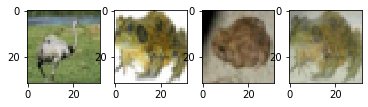

In [11]:
plt.subplot(1, 4, 1)
show_np_array(X_tr[perms[0]][0])
plt.subplot(1, 4, 2)
show_np_array(X_tr[perms[1]][0])
plt.subplot(1, 4, 3)
show_np_array(X_tr[perms[2]][0])
#show_np_array(.34*X_tr[perms[0]][0]+.33*X_tr[perms[1]][0]+.33*X_tr[perms[2]][0])
plt.subplot(1, 4, 4)
show_np_array(X_mixed[0])

In [12]:
Xperms[0]


show_np_array(X_mixed[0])

NameError: name 'Xperms' is not defined